# Quick start

This notebook walks through the core xhycom workflow: opening HYCOM `.ab` files
directly into labelled `xr.Dataset` objects, slicing, and plotting.

In [1]:
import xhycom

Set the paths below to point at your data before running.

In [2]:
GRID_PATH = "/cluster/home/nlo043/NERSC-HYCOM-CICE/TP2a0.10/topo/regional.grid"
BATHY_PATH = "/cluster/home/nlo043/NERSC-HYCOM-CICE/TP2a0.10/topo/depth_TP2a0.10_01"
DATA_PATH = "/nird/datalake/NS9481K/shuang/TP2_output/expt_02.8/"  # directory containing archv.*.ab or archm.*.ab

## Open the grid and bathymetry

In [3]:
ds_grid = xhycom.open_dataset(GRID_PATH)

In [4]:
ds_grid

<xarray.Dataset> Size: 23MB
Dimensions:  (y: 380, x: 400)
Dimensions without coordinates: y, x
Data variables: (12/19)
    plon     (y, x) float64 1MB -94.75 -94.58 -94.42 ... 99.09 98.95 98.82
    plat     (y, x) float64 1MB 39.06 39.16 39.26 39.36 ... 56.39 56.29 56.2
    qlon     (y, x) float64 1MB -94.76 -94.6 -94.43 -94.27 ... 99.07 98.94 98.8
    qlat     (y, x) float64 1MB 38.94 39.04 39.14 39.24 ... 56.47 56.38 56.29
    ulon     (y, x) float64 1MB -94.83 -94.67 -94.5 -94.33 ... 99.16 99.02 98.89
    ulat     (y, x) float64 1MB 39.01 39.11 39.21 39.31 ... 56.43 56.34 56.25
    ...       ...
    scux     (y, x) float64 1MB 1.811e+04 1.813e+04 ... 1.327e+04 1.327e+04
    scuy     (y, x) float64 1MB 1.811e+04 1.813e+04 ... 1.327e+04 1.327e+04
    scvx     (y, x) float64 1MB 1.812e+04 1.814e+04 ... 1.328e+04 1.327e+04
    scvy     (y, x) float64 1MB 1.812e+04 1.814e+04 ... 1.328e+04 1.327e+04
    cori     (y, x) float64 1MB 9.167e-05 9.187e-05 ... 0.0001214 0.0001213
    pasp     (y, x) float64 1MB 1.0 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0 1.0

In [5]:
# Bathymetry — grid= is required to supply dimensions and coordinates
ds_bathy = xhycom.open_dataset(BATHY_PATH, grid=GRID_PATH)

In [6]:
ds_bathy

<xarray.Dataset> Size: 4MB
Dimensions:  (y: 380, x: 400)
Coordinates:
    lon      (y, x) float64 1MB -94.75 -94.58 -94.42 ... 99.09 98.95 98.82
    lat      (y, x) float64 1MB 39.06 39.16 39.26 39.36 ... 56.39 56.29 56.2
Dimensions without coordinates: y, x
Data variables:
    depth    (y, x) float64 1MB nan nan nan nan nan nan ... nan nan nan nan nan

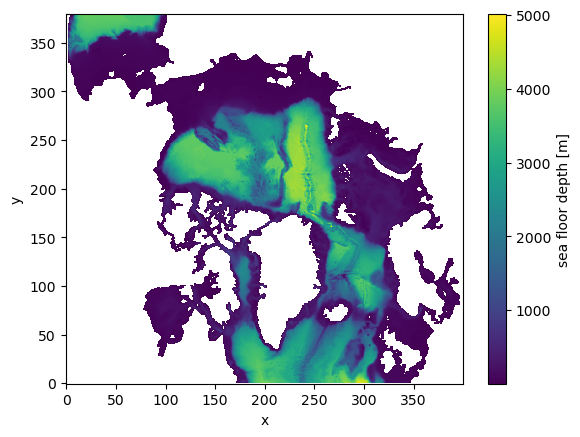

In [7]:
ds_bathy.depth.plot()

In [8]:
land_mask = ds_bathy.depth.isnull()
mask = 1 - land_mask

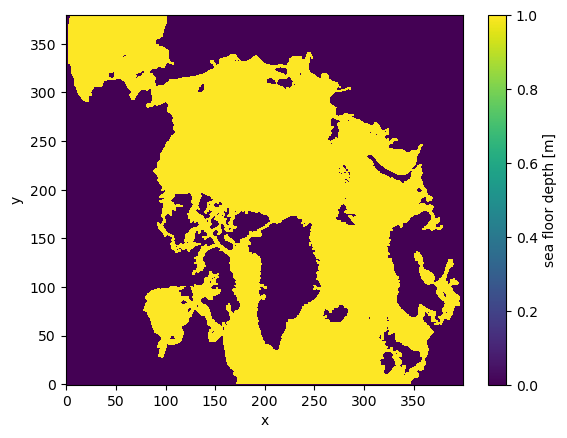

In [9]:
mask.plot()

## Open a single archive snapshot

`open_dataset` auto-detects the file type (archive, grid, bathymetry) from the
`.b` header.  When `grid=` is provided, appropriate `lon`/`lat` coordinates are
attached to each variable based on its staggering point on the Arakawa C-grid.

In [10]:
ds = xhycom.open_dataset(DATA_PATH + "archm.2020_001_12", grid=GRID_PATH)

In [11]:
ds

<xarray.Dataset> Size: 3GB
Dimensions:     (time: 1, y: 380, x: 400, k: 50, ki: 51)
Coordinates:
  * time        (time) object 8B 2020-01-01 00:00:00
    lon         (y, x) float64 1MB -94.75 -94.58 -94.42 ... 99.09 98.95 98.82
    lat         (y, x) float64 1MB 39.06 39.16 39.26 39.36 ... 56.39 56.29 56.2
    lon_u       (y, x) float64 1MB -94.83 -94.67 -94.5 ... 99.16 99.02 98.89
    lat_u       (y, x) float64 1MB 39.01 39.11 39.21 39.31 ... 56.43 56.34 56.25
    lon_v       (y, x) float64 1MB -94.68 -94.52 -94.35 ... 99.0 98.87 98.74
    lat_v       (y, x) float64 1MB 38.99 39.09 39.19 39.29 ... 56.43 56.33 56.24
  * k           (k) int64 400B 1 2 3 4 5 6 7 8 9 ... 42 43 44 45 46 47 48 49 50
    dens        (k) float64 400B 0.1 0.2 0.3 0.4 0.5 ... 28.09 28.1 28.11 28.12
  * ki          (ki) int64 408B 0 1 2 3 4 5 6 7 8 ... 42 43 44 45 46 47 48 49 50
Dimensions without coordinates: y, x
Data variables: (12/83)
    montg1      (time, y, x) float64 1MB nan nan nan nan nan ... nan nan nan nan
    srfhgt      (time, y, x) float64 1MB nan nan nan nan nan ... nan nan nan nan
    oneta       (time, y, x) float64 1MB nan nan nan nan nan ... nan nan nan nan
    surflx      (time, y, x) float64 1MB nan nan nan nan nan ... nan nan nan nan
    wtrflx      (time, y, x) float64 1MB nan nan nan nan nan ... nan nan nan nan
    salflx      (time, y, x) float64 1MB nan nan nan nan nan ... nan nan nan nan
    ...          ...
    CO2_wind    (time, y, x) float64 1MB nan nan nan nan nan ... nan nan nan nan
    ECO_bots    (time, y, x) float64 1MB nan nan nan nan nan ... nan nan nan nan
    surface__1  (time, y, x) float64 1MB nan nan nan nan nan ... nan nan nan nan
    surface__2  (time, y, x) float64 1MB nan nan nan nan nan ... nan nan nan nan
    si_u        (time, y, x) float64 1MB nan nan nan nan nan ... nan nan nan nan
    si_v        (time, y, x) float64 1MB nan nan nan nan nan ... nan nan nan nan
Attributes:
    iversn:   23
    iexpt:    28
    yrflag:   3

Every variable carries CF-style metadata (`long_name`, `units`) read from xhycom's
built-in lookup table:

```python
ds["temp"].attrs   # → {'long_name': 'sea water potential temperature', 'units': 'degC'}
```

Dimension and coordinate attrs are also set:
- `k` / `ki` — layer centres / interfaces, `axis: Z`
- `lon` / `lat` — T-point; `lon_u` / `lat_u` — U-point; `lon_v` / `lat_v` — V-point
- `dens` — target sigma-2 density for each layer

## Slicing

xarray's `isel` (index-based) and `sel` (label-based) selectors work directly.

In [12]:
# Surface temperature at the first time step
sst = ds["temp"].isel(time=0, k=0)

In [13]:
sst

<xarray.DataArray 'temp' (y: 380, x: 400)> Size: 1MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(380, 400))
Coordinates:
    lon      (y, x) float64 1MB -94.75 -94.58 -94.42 ... 99.09 98.95 98.82
    lat      (y, x) float64 1MB 39.06 39.16 39.26 39.36 ... 56.39 56.29 56.2
    lon_u    (y, x) float64 1MB -94.83 -94.67 -94.5 -94.33 ... 99.16 99.02 98.89
    lat_u    (y, x) float64 1MB 39.01 39.11 39.21 39.31 ... 56.43 56.34 56.25
    lon_v    (y, x) float64 1MB -94.68 -94.52 -94.35 -94.19 ... 99.0 98.87 98.74
    lat_v    (y, x) float64 1MB 38.99 39.09 39.19 39.29 ... 56.43 56.33 56.24
    time     object 8B 2020-01-01 00:00:00
    k        int64 8B 1
    dens     float64 8B 0.1
Dimensions without coordinates: y, x
Attributes:
    long_name:  sea water potential temperature
    units:      degC

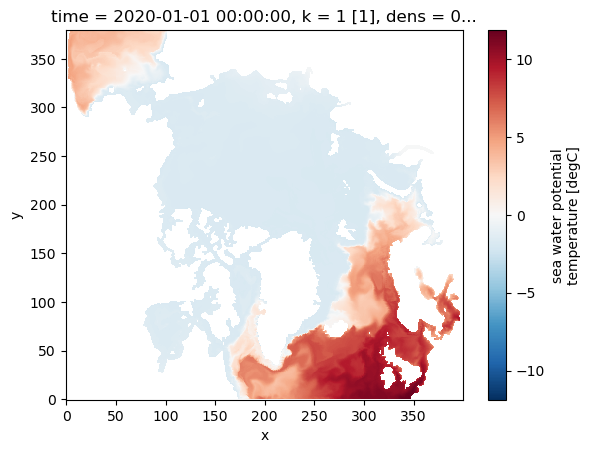

In [14]:
sst.plot()

In [15]:
temp_at_fixed_dens = ds["temp"].isel(time=0).isel(k=13)

In [16]:
temp_at_fixed_dens

<xarray.DataArray 'temp' (y: 380, x: 400)> Size: 1MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(380, 400))
Coordinates:
    lon      (y, x) float64 1MB -94.75 -94.58 -94.42 ... 99.09 98.95 98.82
    lat      (y, x) float64 1MB 39.06 39.16 39.26 39.36 ... 56.39 56.29 56.2
    lon_u    (y, x) float64 1MB -94.83 -94.67 -94.5 -94.33 ... 99.16 99.02 98.89
    lat_u    (y, x) float64 1MB 39.01 39.11 39.21 39.31 ... 56.43 56.34 56.25
    lon_v    (y, x) float64 1MB -94.68 -94.52 -94.35 -94.19 ... 99.0 98.87 98.74
    lat_v    (y, x) float64 1MB 38.99 39.09 39.19 39.29 ... 56.43 56.33 56.24
    time     object 8B 2020-01-01 00:00:00
    k        int64 8B 14
    dens     float64 8B 26.9
Dimensions without coordinates: y, x
Attributes:
    long_name:  sea water potential temperature
    units:      degC

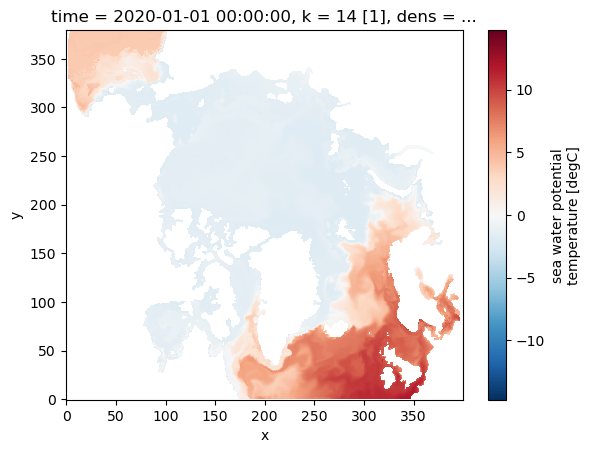

In [17]:
temp_at_fixed_dens.plot()

In [18]:
# Select by layer density instead of layer index
the_same_temp = ds["temp"].isel(time=0).sel(dens=27.0, method="nearest")

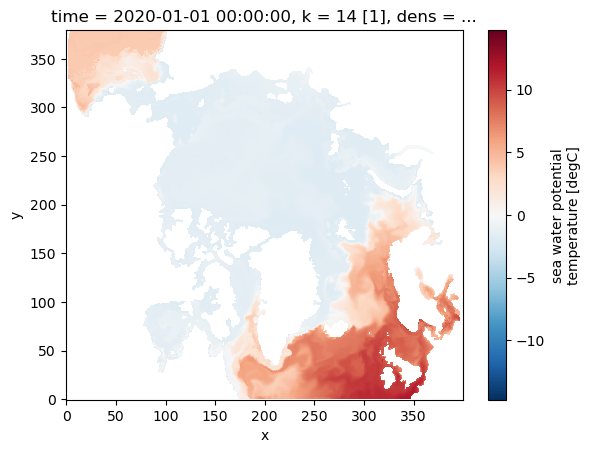

In [19]:
the_same_temp.plot()

In [20]:
# Spatial slice over a lon/lat bounding box
# (use .where() because lon/lat are 2-D curvilinear coordinates)
region_mask = (ds.lon > -30) & (ds.lon < 30) & (ds.lat > 50) & (ds.lat < 80)

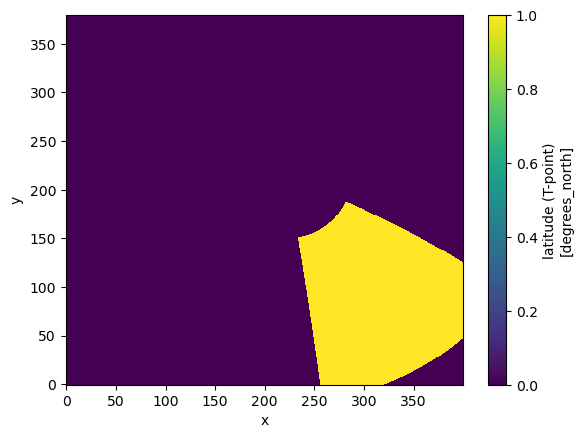

In [21]:
region_mask.plot()

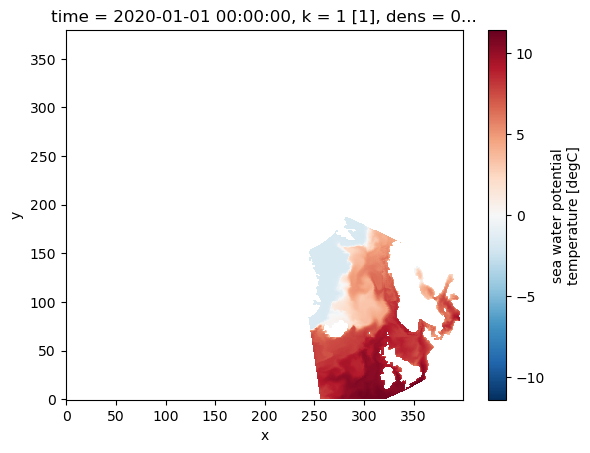

In [22]:
ds["temp"].isel(time=0, k=0).where(region_mask).plot()

## Plotting

In [23]:
sss = ds["salin"].isel(time=0, k=0)

For quick plots, use xarray's in-built plotting.


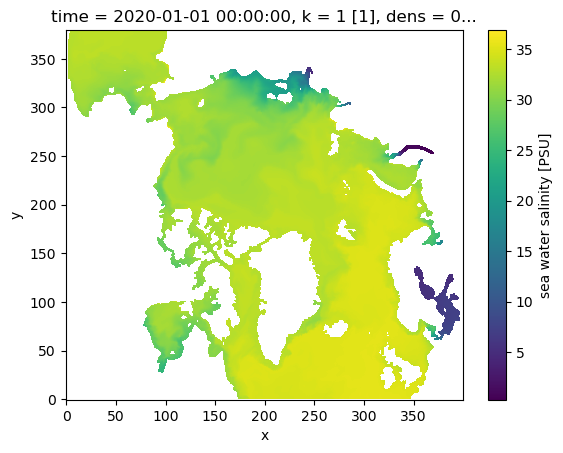

In [24]:
sss.plot()

Because `lon` and `lat` are 2-D curvilinear arrays, use `pcolormesh` directly rather than xarray's `.plot()`.  U-point and V-point variables carry `lon_u`/`lat_u` and `lon_v`/`lat_v` coordinates.

In [25]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

In [26]:
def ArcticMap():

    fig, ax = plt.subplots(
        figsize=(8, 8),
        subplot_kw={"projection": ccrs.NorthPolarStereo(central_longitude=0.0)},
    )

    ax.set_extent([-180, 180, 48, 90], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor=cfeature.COLORS["land"], edgecolor="grey", zorder=2)
    ax.add_feature(cfeature.COASTLINE.with_scale("50m"), edgecolor="grey", linewidth=0.4, zorder=3)
    ax.gridlines()
      
    return fig, ax

In [27]:
def pcolormesh_curvilinear(lon, lat, data, ax=None, **kwargs):

    proj = ax.projection
    pxy = proj.transform_points(ccrs.PlateCarree(), lon, lat)
    px, py = pxy[:, :, 0], pxy[:, :, 1]
    invalid = ~np.isfinite(px) | ~np.isfinite(py)
    px = np.where(invalid, 0.0, px)
    py = np.where(invalid, 0.0, py)
    data = np.where(invalid, np.nan, data)
    return ax.pcolormesh(px, py, data, **kwargs)

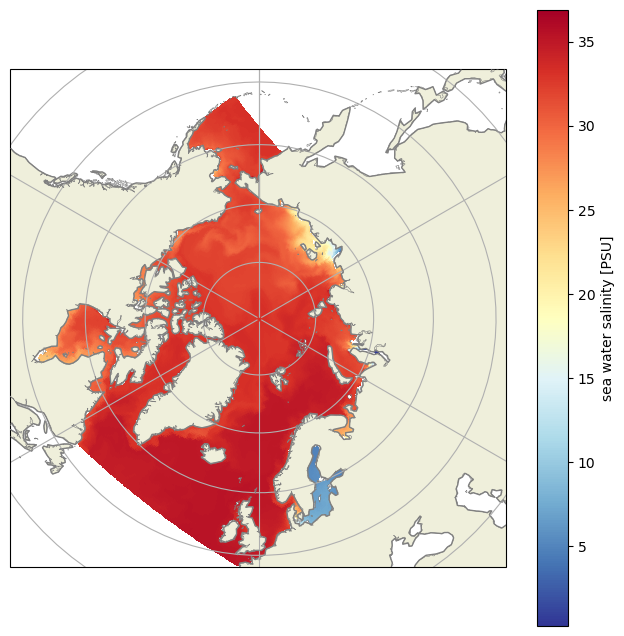

In [28]:
fig, ax = ArcticMap()
p = pcolormesh_curvilinear(sss.lon.values, sss.lat.values, sss.values, ax=ax, cmap="RdYlBu_r")
fig.colorbar(p, ax=ax, label=f"{sss.attrs['long_name']} [{sss.attrs['units']}]")

In [29]:
u = ds["u-vel."].isel(time=0, k=0)

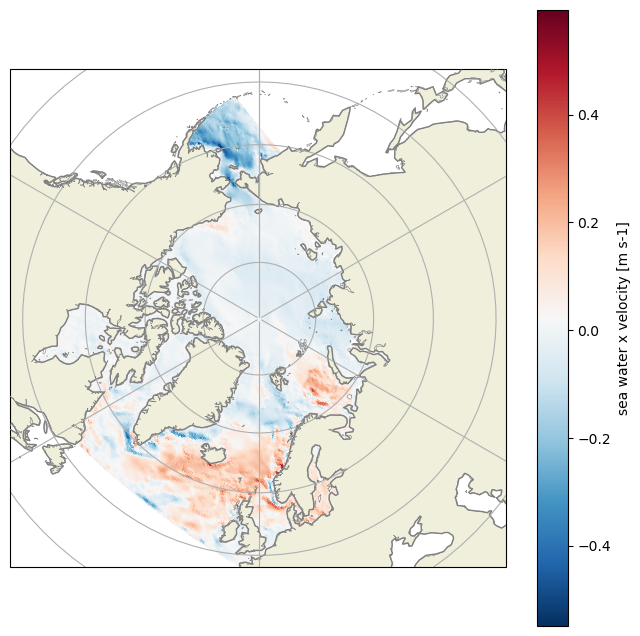

In [30]:
# U-point variable — use lon_u / lat_u

fig, ax = ArcticMap()
p = pcolormesh_curvilinear(u.lon_u.values, u.lat_u.values, u.values, ax=ax, cmap="RdBu_r")
fig.colorbar(p, ax=ax, label=f"{u.attrs['long_name']} [{u.attrs['units']}]")

## Open a time series

Pass a directory or a glob pattern and xhycom discovers all matching `.ab` file pairs, parses their `.b` headers, and returns a single Dataset with a `time` dimension spanning every snapshot in chronological order.

To understand the memory and time cost of each approach, we use the `memory_profiler` extension:

- `%%time` reports wall-clock and CPU time for the cell.
- `%%memit` reports **peak memory** (the high-water mark reached during the cell) and **increment** (how much extra memory was allocated on top of what was already in use before the cell ran).

We start by opening the first 9 daily files of 2020 **without** chunking, so all field data is read eagerly into RAM.

In [31]:
%load_ext memory_profiler

In [32]:
%%time
%%memit
ds = xhycom.open_mfdataset(DATA_PATH + "archm.2020_00*", grid=GRID_PATH)

peak memory: 58159.53 MiB, increment: 54644.73 MiB
CPU times: user 17.9 s, sys: 7.5 s, total: 25.4 s
Wall time: 25.6 s


The output tells us two things:

- **Increment: ~54 GB** — xhycom read every `.a` binary file in full and allocated one array per variable per time step. With only 9 files and 83 variables this is already enormous; a full year would consume hundreds of GB, and a multi-decade archive would be completely unworkable.
- **Wall time: ~26 s** — the call blocked for 26 seconds while all that data was transferred from disk into RAM.

:::{note}
`%%time` and `%%memit` are optional. Remove them from any cell if you are not interested in the profiling output — they have no effect on the returned data.
:::

In [44]:
ds

<xarray.Dataset> Size: 29GB
Dimensions:     (time: 9, y: 380, x: 400, k: 50, ki: 51)
Coordinates:
  * time        (time) object 72B 2020-01-01 00:00:00 ... 2020-01-09 00:00:00
    lon         (y, x) float64 1MB -94.75 -94.58 -94.42 ... 99.09 98.95 98.82
    lat         (y, x) float64 1MB 39.06 39.16 39.26 39.36 ... 56.39 56.29 56.2
    lon_u       (y, x) float64 1MB -94.83 -94.67 -94.5 ... 99.16 99.02 98.89
    lat_u       (y, x) float64 1MB 39.01 39.11 39.21 39.31 ... 56.43 56.34 56.25
    lon_v       (y, x) float64 1MB -94.68 -94.52 -94.35 ... 99.0 98.87 98.74
    lat_v       (y, x) float64 1MB 38.99 39.09 39.19 39.29 ... 56.43 56.33 56.24
  * k           (k) int64 400B 1 2 3 4 5 6 7 8 9 ... 42 43 44 45 46 47 48 49 50
    dens        (k) float64 400B 0.1 0.2 0.3 0.4 0.5 ... 28.09 28.1 28.11 28.12
  * ki          (ki) int64 408B 0 1 2 3 4 5 6 7 8 ... 42 43 44 45 46 47 48 49 50
Dimensions without coordinates: y, x
Data variables: (12/83)
    montg1      (time, y, x) float64 11MB nan nan nan nan ... nan nan nan nan
    srfhgt      (time, y, x) float64 11MB nan nan nan nan ... nan nan nan nan
    oneta       (time, y, x) float64 11MB nan nan nan nan ... nan nan nan nan
    surflx      (time, y, x) float64 11MB nan nan nan nan ... nan nan nan nan
    wtrflx      (time, y, x) float64 11MB nan nan nan nan ... nan nan nan nan
    salflx      (time, y, x) float64 11MB nan nan nan nan ... nan nan nan nan
    ...          ...
    CO2_wind    (time, y, x) float64 11MB nan nan nan nan ... nan nan nan nan
    ECO_bots    (time, y, x) float64 11MB nan nan nan nan ... nan nan nan nan
    surface__1  (time, y, x) float64 11MB nan nan nan nan ... nan nan nan nan
    surface__2  (time, y, x) float64 11MB nan nan nan nan ... nan nan nan nan
    si_u        (time, y, x) float64 11MB nan nan nan nan ... nan nan nan nan
    si_v        (time, y, x) float64 11MB nan nan nan nan ... nan nan nan nan
Attributes:
    iversn:   23
    iexpt:    28
    yrflag:   3

In [45]:
ds.time

<xarray.DataArray 'time' (time: 9)> Size: 72B
array([cftime.DatetimeGregorian(2020, 1, 1, 0, 0, 0, 0, has_year_zero=False),
       cftime.DatetimeGregorian(2020, 1, 2, 0, 0, 0, 0, has_year_zero=False),
       cftime.DatetimeGregorian(2020, 1, 3, 0, 0, 0, 0, has_year_zero=False),
       cftime.DatetimeGregorian(2020, 1, 4, 0, 0, 0, 0, has_year_zero=False),
       cftime.DatetimeGregorian(2020, 1, 5, 0, 0, 0, 0, has_year_zero=False),
       cftime.DatetimeGregorian(2020, 1, 6, 0, 0, 0, 0, has_year_zero=False),
       cftime.DatetimeGregorian(2020, 1, 7, 0, 0, 0, 0, has_year_zero=False),
       cftime.DatetimeGregorian(2020, 1, 8, 0, 0, 0, 0, has_year_zero=False),
       cftime.DatetimeGregorian(2020, 1, 9, 0, 0, 0, 0, has_year_zero=False)],
      dtype=object)
Coordinates:
  * time     (time) object 72B 2020-01-01 00:00:00 ... 2020-01-09 00:00:00

In [46]:
# Time-mean surface salinity
smean = ds["salin"].isel(k=0).mean("time")
smean

<xarray.DataArray 'salin' (y: 380, x: 400)> Size: 1MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(380, 400))
Coordinates:
    lon      (y, x) float64 1MB -94.75 -94.58 -94.42 ... 99.09 98.95 98.82
    lat      (y, x) float64 1MB 39.06 39.16 39.26 39.36 ... 56.39 56.29 56.2
    lon_u    (y, x) float64 1MB -94.83 -94.67 -94.5 -94.33 ... 99.16 99.02 98.89
    lat_u    (y, x) float64 1MB 39.01 39.11 39.21 39.31 ... 56.43 56.34 56.25
    lon_v    (y, x) float64 1MB -94.68 -94.52 -94.35 -94.19 ... 99.0 98.87 98.74
    lat_v    (y, x) float64 1MB 38.99 39.09 39.19 39.29 ... 56.43 56.33 56.24
    k        int64 8B 1
    dens     float64 8B 0.1
Dimensions without coordinates: y, x
Attributes:
    long_name:  sea water salinity
    units:      PSU

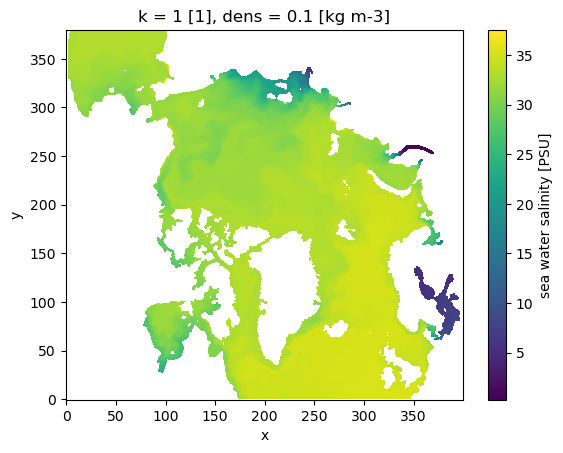

In [47]:
smean.plot()

## Lazy loading with Dask

The fix is the `chunks` argument. With `chunks={"time": 1}`, xhycom does **not** read the `.a` binary files at open time. Instead it:

1. Parses only the lightweight `.b` text headers — one per file — to learn field names, layer structure, and timestamps.
2. Builds a [Dask](https://docs.dask.org) computation graph: a recipe that describes *how* to read each array when values are eventually needed.
3. Returns a Dataset whose data variables carry `dask.array` instead of actual numbers.

Nothing is read from disk until you explicitly ask for values via `.compute()`, `.load()`, or `.plot()`.

Other useful chunk strategies:

| `chunks=` | When to use |
|-----------|-------------|
| `{"time": 1}` | Long time series; process one snapshot at a time (most common) |
| `{"k": 1}` | Depth-by-depth analysis within a single snapshot |
| `{"time": 1, "k": 1}` | Layer-by-layer pass over a long time series |

In [48]:
%%time
%%memit
ds_lazy = xhycom.open_mfdataset(DATA_PATH + "archm.2020_00*", grid=GRID_PATH, chunks={"time": 1})

peak memory: 31139.78 MiB, increment: 130.00 MiB
CPU times: user 481 ms, sys: 72.9 ms, total: 554 ms
Wall time: 678 ms


The contrast with the eager approach is stark:

- **Increment: 130 MB** instead of ~54 GB — xhycom only parsed the small `.b` text headers; no binary data was read.
- **Wall time: 678 ms** instead of ~26 s — headers for all 9 files were parsed in parallel.

The Dataset header reports `Size: 29 GB` because that is how large the data *would be* if fully loaded. Right now, virtually none of it is in RAM.

In [49]:
ds_lazy   # DataArrays show 'dask.array' — nothing read yet

<xarray.Dataset> Size: 29GB
Dimensions:     (y: 380, x: 400, time: 9, k: 50, ki: 51)
Coordinates:
    lon         (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lat         (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lon_u       (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lat_u       (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lon_v       (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lat_v       (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
  * time        (time) object 72B 2020-01-01 00:00:00 ... 2020-01-09 00:00:00
  * k           (k) int64 400B 1 2 3 4 5 6 7 8 9 ... 42 43 44 45 46 47 48 49 50
    dens        (k) float64 400B dask.array<chunksize=(50,), meta=np.ndarray>
  * ki          (ki) int64 408B 0 1 2 3 4 5 6 7 8 ... 42 43 44 45 46 47 48 49 50
Dimensions without coordinates: y, x
Data variables: (12/83)
    montg1      (time, y, x) float64 11MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    srfhgt      (time, y, x) float64 11MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    oneta       (time, y, x) float64 11MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    surflx      (time, y, x) float64 11MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    wtrflx      (time, y, x) float64 11MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    salflx      (time, y, x) float64 11MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    ...          ...
    CO2_wind    (time, y, x) float64 11MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    ECO_bots    (time, y, x) float64 11MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    surface__1  (time, y, x) float64 11MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    surface__2  (time, y, x) float64 11MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    si_u        (time, y, x) float64 11MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    si_v        (time, y, x) float64 11MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
Attributes:
    iversn:   23
    iexpt:    28
    yrflag:   3

In [50]:
smean = ds_lazy["salin"].isel(k=0).mean("time")
smean

<xarray.DataArray 'salin' (y: 380, x: 400)> Size: 1MB
dask.array<mean_agg-aggregate, shape=(380, 400), dtype=float64, chunksize=(380, 400), chunktype=numpy.ndarray>
Coordinates:
    lon      (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lat      (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lon_u    (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lat_u    (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lon_v    (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lat_v    (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    k        int64 8B 1
    dens     float64 8B dask.array<chunksize=(), meta=np.ndarray>
Dimensions without coordinates: y, x
Attributes:
    long_name:  sea water salinity
    units:      PSU

`smean` is still a Dask array — the chain `.isel(k=0).mean("time")` has been *scheduled* but not yet executed. Dask simply extended the computation graph: it now describes "read surface salinity from each of the 9 files and average them." Nothing has been read from disk yet.

In [55]:
%%time
%%memit

smean.load()

peak memory: 31197.08 MiB, increment: 55.16 MiB
CPU times: user 609 ms, sys: 122 ms, total: 731 ms
Wall time: 866 ms


- **Increment: 55 MB** — Dask processed one time step at a time: read one surface-salinity slab, add it to the running sum, discard the slab, repeat. Peak working memory is proportional to a single slab (≈ 1 MB), not the full 9-step stack.
- **Wall time: 866 ms** — the actual disk reads, which were deferred until this `.load()` call.

In [56]:
smean

<xarray.DataArray 'salin' (y: 380, x: 400)> Size: 1MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(380, 400))
Coordinates:
    lon      (y, x) float64 1MB -94.75 -94.58 -94.42 ... 99.09 98.95 98.82
    lat      (y, x) float64 1MB 39.06 39.16 39.26 39.36 ... 56.39 56.29 56.2
    lon_u    (y, x) float64 1MB -94.83 -94.67 -94.5 -94.33 ... 99.16 99.02 98.89
    lat_u    (y, x) float64 1MB 39.01 39.11 39.21 39.31 ... 56.43 56.34 56.25
    lon_v    (y, x) float64 1MB -94.68 -94.52 -94.35 -94.19 ... 99.0 98.87 98.74
    lat_v    (y, x) float64 1MB 38.99 39.09 39.19 39.29 ... 56.43 56.33 56.24
    k        int64 8B 1
    dens     float64 8B 0.1
Dimensions without coordinates: y, x
Attributes:
    long_name:  sea water salinity
    units:      PSU

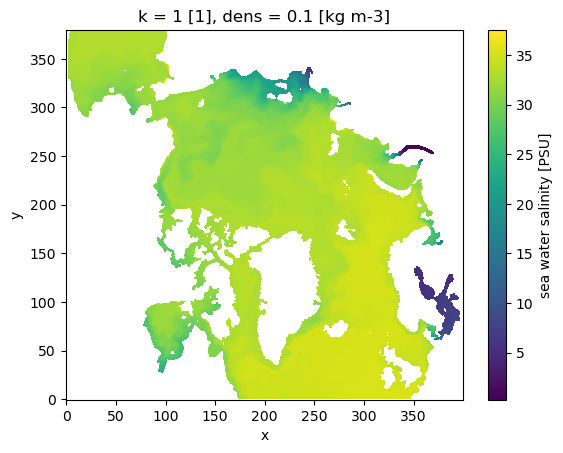

In [57]:
smean = ds_lazy["salin"].isel(k=0).mean("time")
smean.plot()

Now let's scale up to a full year of daily output — 365 files — still with `chunks={"time": 1}`.

In [58]:
%%time
%%memit

ds_lazy = xhycom.open_mfdataset(DATA_PATH + "archm.2020*", grid=GRID_PATH, chunks={"time": 1})

peak memory: 31565.19 MiB, increment: 424.26 MiB
CPU times: user 11 s, sys: 365 ms, total: 11.3 s
Wall time: 11.5 s


Even with 40× more files the open call stays lightweight:

- **Increment: 424 MB** — mostly the Dask graph metadata describing 365 files × 83 variables. The binary data is still untouched on disk.
- **Wall time: 11.5 s** — the `.b` headers for all 365 files were parsed in parallel.

For comparison, opening 365 files eagerly would require roughly 2 TB of RAM.

In [60]:
%%time
%%memit

ssh_mean = ds_lazy.srfhgt.mean(dim=["y", "x"]).compute()

peak memory: 31565.19 MiB, increment: 0.00 MiB
CPU times: user 5.01 s, sys: 182 ms, total: 5.2 s
Wall time: 6.82 s


- **Increment: 0 MB** — Dask read one sea-surface-height slab at a time, reduced it to a scalar, and discarded the slab before reading the next. Peak working memory never exceeded the size of one snapshot, regardless of how many time steps the archive contains.
- **Wall time: 6.82 s** — time to stream through 365 daily snapshots and reduce each to a single number.

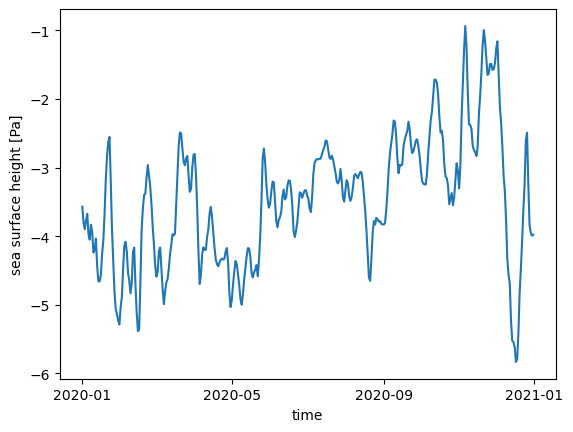

In [61]:
ssh_mean.plot()

Finally, the full archive — every daily file from September 1992 to December 2024, covering over 30 years.

In [62]:
%%time
%%memit

ds_lazy = xhycom.open_mfdataset(DATA_PATH + "archm.*", grid=GRID_PATH, chunks={"time": 1})

peak memory: 39765.19 MiB, increment: 8200.00 MiB
CPU times: user 6min 44s, sys: 9.46 s, total: 6min 53s
Wall time: 6min 52s


The Dataset now spans **11,805 snapshots** (1992–2024) and represents **38 TB** of data — none of which is in RAM. The memory increment reflects the Dask graph built to describe all those deferred read operations.

In [63]:
ds_lazy

<xarray.Dataset> Size: 38TB
Dimensions:     (y: 380, x: 400, time: 11805, k: 50, ki: 51)
Coordinates:
    lon         (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lat         (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lon_u       (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lat_u       (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lon_v       (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lat_v       (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
  * time        (time) object 94kB 1992-09-06 00:00:00 ... 2024-12-31 00:00:00
  * k           (k) int64 400B 1 2 3 4 5 6 7 8 9 ... 42 43 44 45 46 47 48 49 50
    dens        (k) float64 400B dask.array<chunksize=(50,), meta=np.ndarray>
  * ki          (ki) int64 408B 0 1 2 3 4 5 6 7 8 ... 42 43 44 45 46 47 48 49 50
Dimensions without coordinates: y, x
Data variables: (12/83)
    montg1      (time, y, x) float64 14GB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    srfhgt      (time, y, x) float64 14GB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    oneta       (time, y, x) float64 14GB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    surflx      (time, y, x) float64 14GB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    wtrflx      (time, y, x) float64 14GB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    salflx      (time, y, x) float64 14GB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    ...          ...
    CO2_wind    (time, y, x) float64 14GB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    ECO_bots    (time, y, x) float64 14GB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    surface__1  (time, y, x) float64 14GB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    surface__2  (time, y, x) float64 14GB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    si_u        (time, y, x) float64 14GB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    si_v        (time, y, x) float64 14GB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
Attributes:
    iversn:   23
    iexpt:    28
    yrflag:   3

In [64]:
%%time
%%memit

ssh_mean = ds_lazy.srfhgt.mean(dim=["y", "x"]).compute()

peak memory: 37105.51 MiB, increment: 5.48 MiB
CPU times: user 3min 5s, sys: 4.99 s, total: 3min 10s
Wall time: 3min 59s


- **Increment: 5.5 MB** — even for a 30-year record, Dask's chunk-by-chunk execution means peak working memory is determined by a single time step's data, not the size of the archive.
- **Wall time: ~4 min** — time to stream through 11,805 daily `.ab` files and reduce sea-surface height to a scalar time series.

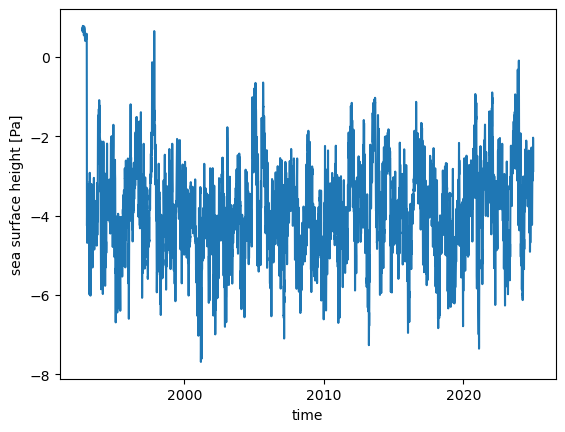

In [65]:
ssh_mean.plot()